In [1]:
import matplotlib.pyplot as plt   # view codes
import yfinance as yf   # the datas
import pandas as pd   # manipulator


# Modelo para teste
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score

)

Download dos Dados

In [2]:
code = "AAPL"  # Dados das ações da Apple
start = "2015-01-01"
end = "2026-01-01"

datas = yf.download(code, start=start, end=end, multi_level_index=False)

# View datas
datas

/tmp/ipython-input-1763441942.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datas = yf.download(code, start=start, end=end, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.237547,24.705316,23.798597,24.694231,212818400
2015-01-05,23.554739,24.086799,23.368519,24.006990,257142000
2015-01-06,23.556957,23.816336,23.195599,23.619031,263188400
2015-01-07,23.887285,23.987046,23.654508,23.765354,160423600
2015-01-08,24.805086,24.862726,24.097889,24.215387,237458000
...,...,...,...,...,...
2025-12-24,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,273.399994,275.369995,272.859985,274.160004,21521800
2025-12-29,273.760010,274.359985,272.350006,272.690002,23715200


Formatação dos Dados

In [3]:
# Convert to datetime
#datas.index


# Format and columns that will be used to predict
datas = datas[["Close"]].reset_index()

datas.columns = ["ds", "y"]

datas

,ds,y
0,2015-01-02,24.237547
1,2015-01-05,23.554739
2,2015-01-06,23.556957
3,2015-01-07,23.887285
4,2015-01-08,24.805086
...,...,...
2761,2025-12-24,273.809998
2762,2025-12-26,273.399994
2763,2025-12-29,273.760010
2764,2025-12-30,273.079987


Desenvolvimento do Modelo

O modelo utilizado neste projeto é uma adaptação de modelos de previsão de séries temporais inspirados em abordagens como Prophet e NeuralProphet. Foi desenvolvido um modelo baseado em redes neurais, que aprende padrões temporais a partir de janelas deslizantes dos preços históricos das ações.

Arquitetura do Modelo

Objetivo

Prever o preço futuro da ação (Close) com base em preços passados.

Entrada

Uma sequência de preços passados (ex: últimos 10 anos)

Modelo

Rede Neural do tipo:

LSTM (mais forte, recomendado)

Saída

Preço previsto para o próximo ano (ou próximos N anos)

In [4]:
import torch
import torch.nn as nn


In [5]:
class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(StockLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :]

        out = self.fc(out)
        return out


Transformação dos dados num formato compreensivel pelo Modelo 

In [6]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler


In [7]:
# datas tem colunas: ds, y
datas = datas.copy()
datas["ds"] = pd.to_datetime(datas["ds"])
datas = datas.sort_values("ds").reset_index(drop=True)

datas["r"] = np.log(datas["y"] / datas["y"].shift(1))
datas = datas.dropna().reset_index(drop=True)

returns = datas["r"].values.reshape(-1, 1)
print("Retornos:", returns.shape, "Preço:", datas["y"].shape)



Retornos: (2765, 1) Preço: (2765,)


In [8]:
# Normalization of the returns
scaler_r = StandardScaler()
returns_scaled = scaler_r.fit_transform(returns)


In [9]:
# Function to create sequences
LOOKBACK = 60

def create_sequences_1d(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences_1d(returns_scaled, LOOKBACK)

X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (N, 60, 1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (N, 1)

train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test   = X[train_size:], y[train_size:]

X_train.shape, X_test.shape


(torch.Size([2164, 60, 1]), torch.Size([541, 60, 1]))

Treinamento, Teste e Previsão do Modelo

In [10]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


Parte 1 - Treinamento

In [11]:
# Nº of iterations
epochs = 30
for epoch in range(epochs):
    model.train()
    pred = model(X_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.6f}")



Epoch [5/30] Loss: 1.035424
Epoch [10/30] Loss: 1.033743
Epoch [15/30] Loss: 1.032726
Epoch [20/30] Loss: 1.031178
Epoch [25/30] Loss: 1.030689
Epoch [30/30] Loss: 1.030296


Parte 2 - Teste

In [12]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)

# Convert to numpy
predictions = predictions.numpy()
y_test_np = y_test.numpy()


mse = mean_squared_error(y_test_np, predictions)
mae = mean_absolute_error(y_test_np, predictions)
r2 = r2_score(y_test_np, predictions)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)


MSE: 0.8804796934127808
MAE: 0.6205200552940369
R²: -0.0027430057525634766


Parte 3 - Previsão para 2026

In [13]:
model.eval()

# sequência final (últimos 60 retornos normalizados)
last_seq = returns_scaled[-LOOKBACK:]
last_seq = torch.tensor(last_seq, dtype=torch.float32).unsqueeze(0)

future_days = 252  # dias úteis de 2026
future_returns_scaled = []

with torch.no_grad():
    for _ in range(future_days):
        next_r_scaled = model(last_seq)

        future_returns_scaled.append(next_r_scaled.item())

        next_r_scaled_3d = next_r_scaled.unsqueeze(2)

        last_seq = torch.cat((last_seq[:, 1:, :], next_r_scaled_3d), dim=1)

# desnormalizar retornos previstos
future_returns = scaler_r.inverse_transform(
    np.array(future_returns_scaled).reshape(-1, 1)
).flatten()


In [14]:
last_real_date = datas["ds"].iloc[-1]
last_real_price = float(datas["y"].iloc[-1])

# datas futuras (business days) começando no próximo dia útil
future_dates = pd.bdate_range(
    start=last_real_date + pd.offsets.BDay(1),
    periods=future_days
)

# reconstruir preços por log-retorno
future_prices = []
p = last_real_price
for r in future_returns:
    p = p * np.exp(r)
    future_prices.append(p)

future_prices = np.array(future_prices)


Grafico de visualização

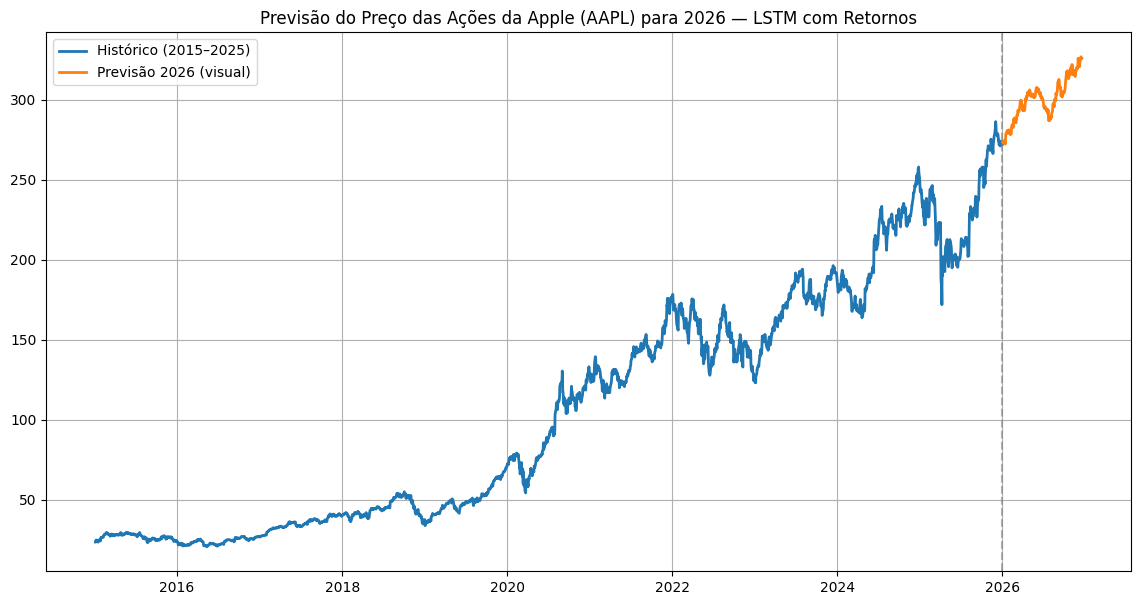

In [16]:
# volatilidade histórica diária (retornos do histórico)
hist_returns = datas["y"].pct_change().dropna().values
sigma = hist_returns.std()

# "zig-zag" para visual
noise = np.random.normal(0, sigma*0.25, size=len(future_prices))
future_prices_visual = future_prices * np.cumprod(1 + noise)

plt.figure(figsize=(14,7))
plt.title("Previsão do Preço das Ações da Apple (AAPL) para 2026 — LSTM com Retornos")
plt.plot(datas["ds"], datas["y"], label="Histórico (2015–2025)", linewidth=2)
plt.plot(future_dates, future_prices_visual, label="Previsão 2026 (visual)", linewidth=2)
plt.axvline(x=datas["ds"].iloc[-1], color="gray", linestyle="--", alpha=0.6)
plt.legend(); plt.grid(True)
plt.show()

